In [9]:
# How to handle column with mixed values
# 2 types -> a. (single cell have both numbers and letters -> together), b. (single column have both letter and number -> not together)
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv('../../../DataBox/titanic_mixed_var.csv')

Text(0.5, 1.0, 'Passengers travelling with')

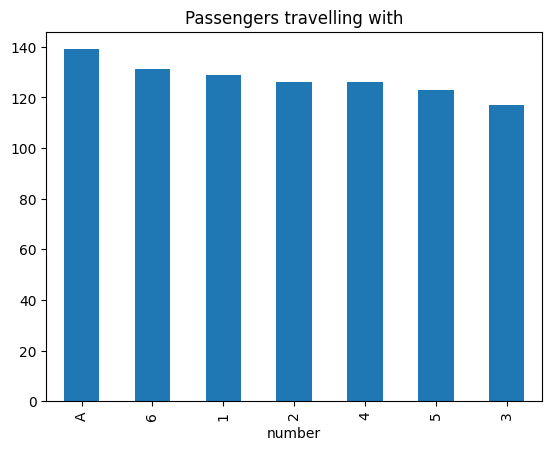

In [11]:
# Check The Distribution

fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

# A -> Travling alone.

In [12]:
# Extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')

# Extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

# Regex -> letter ([A-Z]) but only captures the digits (\d+)
df['cabin_num'] = df['Cabin'].str.extract(r'[A-Z](\d+)') 

# Capture the first letter (Deck)
df['cabin_cat'] = df['Cabin'].str[0] 

<Axes: xlabel='cabin_cat'>

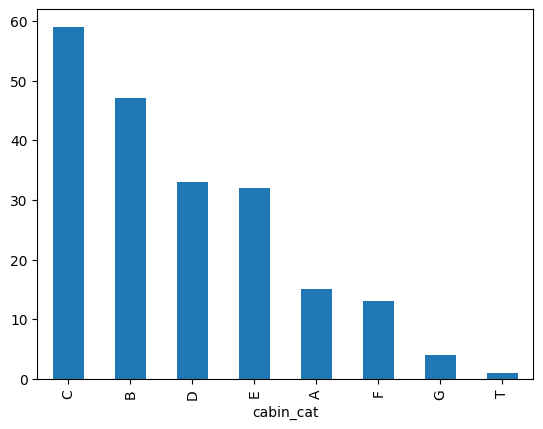

In [13]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [14]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])